# Data Cleaning & Feature Engineering — Beverage Sales History

**Project**: OptiWMS Demand Forecasting Pipeline (v3)  
**Prerequisite**: `01_eda_and_data_profiling.ipynb`  
**Output**: `beverage_panel_features.parquet` — production-ready feature panel

---

## Approach
Every cleaning and engineering decision below is **justified by findings from the EDA notebook**. We reference specific EDA sections to maintain traceability.

## Table of Contents
1. [Data Cleaning](#1-data-cleaning)
2. [Aggregation to Warehouse Level](#2-aggregation-to-warehouse-level)
3. [Feature Engineering](#3-feature-engineering)
4. [Train/Validation/Test Split](#4-trainvalidationtest-split)

---
## 1. Data Cleaning

Based on EDA findings, we need to address:
- **Negative values** (EDA §3.3): ~0.08% of rows — confirmed as returns/credit notes
- **Categorical typos** (EDA §3.5): "Grocry" → "Grocery", "Bakry" → "Bakery", " Eatery " → "Eatery"
- **Size inconsistencies** (EDA §3.5): "small" → "Small", empty → "Unknown"
- **No missing values** — nothing to impute (EDA §3.1)
- **No duplicates** — nothing to deduplicate (EDA §3.2)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 11})

DATA_DIR = '../../Dataset Beverage Sales Histsory'

# Load datasets
transactions = pd.read_csv(f'{DATA_DIR}/transactions_history_final.csv')
outlet_master = pd.read_csv(f'{DATA_DIR}/outlet_master.csv')
holidays = pd.read_csv(f'{DATA_DIR}/holiday_list.csv')
seasonality = pd.read_csv(f'{DATA_DIR}/distributor_seasonality_details.csv')

print(f"✅ Loaded {len(transactions):,} transactions")
print(f"   Negative volume rows: {(transactions['Volume_Liters'] < 0).sum():,}")

✅ Loaded 2,376,389 transactions
   Negative volume rows: 4,753


In [2]:
# 1.1 Handle Negative Values
# Decision: Clip to zero — for warehouse-level forecasting, returns shouldn't reduce demand
# (demand existed, the return is a separate process)
print("BEFORE cleaning:")
print(f"  Negative volumes: {(transactions['Volume_Liters'] < 0).sum():,}")
print(f"  Volume range: [{transactions['Volume_Liters'].min():.1f}, {transactions['Volume_Liters'].max():.1f}]")

transactions['Volume_Liters'] = transactions['Volume_Liters'].clip(lower=0)
transactions['Total_Bill_Value'] = transactions['Total_Bill_Value'].clip(lower=0)

print("\nAFTER cleaning:")
print(f"  Negative volumes: {(transactions['Volume_Liters'] < 0).sum():,}")
print(f"  Volume range: [{transactions['Volume_Liters'].min():.1f}, {transactions['Volume_Liters'].max():.1f}]")

BEFORE cleaning:
  Negative volumes: 4,753
  Volume range: [-956.4, 9438.6]

AFTER cleaning:
  Negative volumes: 0
  Volume range: [0.0, 9438.6]


In [3]:
# 1.2 Fix Categorical Typos in outlet_master
print("BEFORE fixing outlet types:")
print(outlet_master['Outlet_Type'].value_counts().to_string())

type_mapping = {
    'Grocry': 'Grocery',
    'Bakry': 'Bakery', 
    ' Eatery ': 'Eatery'
}
outlet_master['Outlet_Type'] = outlet_master['Outlet_Type'].replace(type_mapping).str.strip()

print("\nAFTER fixing:")
print(outlet_master['Outlet_Type'].value_counts().to_string())

BEFORE fixing outlet types:
Outlet_Type
Hotel       2797
Grocery     2768
SMMT        2723
Pharmacy    2691
Kiosk       2691
Bakery      2678
Eatery      2667
Bakry        395
Grocry       390
 Eatery      200

AFTER fixing:
Outlet_Type
Grocery     3158
Bakery      3073
Eatery      2867
Hotel       2797
SMMT        2723
Pharmacy    2691
Kiosk       2691


In [4]:
# 1.3 Fix Size Inconsistencies
print("BEFORE fixing sizes:")
print(outlet_master['Outlet_Size'].value_counts(dropna=False).to_string())

outlet_master['Outlet_Size'] = outlet_master['Outlet_Size'].str.strip().str.title()
outlet_master['Outlet_Size'] = outlet_master['Outlet_Size'].replace({'': 'Unknown', np.nan: 'Unknown'})
outlet_master.loc[outlet_master['Outlet_Size'].isna() | (outlet_master['Outlet_Size'] == ''), 'Outlet_Size'] = 'Unknown'

print("\nAFTER fixing:")
print(outlet_master['Outlet_Size'].value_counts(dropna=False).to_string())

BEFORE fixing sizes:
Outlet_Size
Small          9672
Medium         5702
Large          2887
Extra Large     943
small           600
NaN             196

AFTER fixing:
Outlet_Size
Small          10272
Medium          5702
Large           2887
Extra Large      943
Unknown          196


In [5]:
# 1.4 Data Quality Validation — Before/After Summary
print("📋 DATA QUALITY VALIDATION")
print(f"  Total rows: {len(transactions):,}")
print(f"  Null values: {transactions.isnull().sum().sum()}")
print(f"  Negative volumes: {(transactions['Volume_Liters'] < 0).sum()}")
print(f"  Outlet type unique: {outlet_master['Outlet_Type'].nunique()} → {sorted(outlet_master['Outlet_Type'].unique())}")
print(f"  Outlet size unique: {outlet_master['Outlet_Size'].nunique()} → {sorted(outlet_master['Outlet_Size'].unique())}")
print("\n✅ Cleaning complete — data is ready for aggregation")

📋 DATA QUALITY VALIDATION
  Total rows: 2,376,389


  Null values: 0
  Negative volumes: 0
  Outlet type unique: 7 → ['Bakery', 'Eatery', 'Grocery', 'Hotel', 'Kiosk', 'Pharmacy', 'SMMT']
  Outlet size unique: 5 → ['Extra Large', 'Large', 'Medium', 'Small', 'Unknown']

✅ Cleaning complete — data is ready for aggregation


---
## 2. Aggregation to Warehouse Level

We aggregate from outlet-level (20,000 outlets) to **warehouse-level** — summing all outlet volumes into a single Colombo Main Warehouse view, per SKU per month.

**Rationale**: OptiWMS targets warehouse-level demand forecasting. The 20K outlets are downstream customers; the warehouse needs to know total monthly demand per SKU to plan inventory.

**Target shape**: 10 SKUs × 36 months = **360 rows**

In [6]:
# 2.1 Aggregate: sum volume by SKU × Year × Month
warehouse_agg = transactions.groupby(['Year', 'Month', 'SKU_ID']).agg(
    demand_liters=('Volume_Liters', 'sum'),
    bill_value=('Total_Bill_Value', 'sum'),
    transaction_count=('Volume_Liters', 'count'),
    unique_outlets=('Outlet_ID', 'nunique')
).reset_index()

# Construct proper date column
warehouse_agg['demand_date'] = pd.to_datetime(
    warehouse_agg['Year'].astype(str) + '-' + warehouse_agg['Month'].astype(str).str.zfill(2) + '-01'
)

# Derived: average volume per transaction & price per liter
warehouse_agg['avg_volume_per_tx'] = warehouse_agg['demand_liters'] / warehouse_agg['transaction_count']
warehouse_agg['price_per_liter'] = warehouse_agg['bill_value'] / warehouse_agg['demand_liters'].replace(0, np.nan)

warehouse_agg = warehouse_agg.sort_values(['SKU_ID', 'demand_date']).reset_index(drop=True)

print(f"📊 AGGREGATED PANEL")
print(f"  Shape: {warehouse_agg.shape} (expected: 360 rows × {warehouse_agg.shape[1]} cols)")
print(f"  SKUs: {warehouse_agg['SKU_ID'].nunique()}")
print(f"  Months: {warehouse_agg['demand_date'].nunique()}")
print(f"  Date range: {warehouse_agg['demand_date'].min()} to {warehouse_agg['demand_date'].max()}")
display(warehouse_agg.head(12))

📊 AGGREGATED PANEL
  Shape: (360, 10) (expected: 360 rows × 10 cols)
  SKUs: 10
  Months: 36
  Date range: 2023-01-01 00:00:00 to 2025-12-01 00:00:00


,Year,Month,SKU_ID,demand_liters,bill_value,transaction_count,unique_outlets,demand_date,avg_volume_per_tx,price_per_liter
0,2023,1,SKU_01,179240.355252,5.270597e+07,7934,7382,2023-01-01,22.591424,294.051936
1,2023,2,SKU_01,179108.804471,5.307524e+07,7920,7378,2023-02-01,22.614748,296.329586
2,2023,3,SKU_01,173597.228637,5.110312e+07,8034,7407,2023-03-01,21.607820,294.377515
3,2023,4,SKU_01,246958.893054,7.291818e+07,8055,7456,2023-04-01,30.659080,295.264456
4,2023,5,SKU_01,134684.179162,4.000817e+07,8090,7500,2023-05-01,16.648230,297.051778
5,2023,6,SKU_01,134499.354791,3.973409e+07,7924,7372,2023-06-01,16.973669,295.422148
6,2023,7,SKU_01,172473.560757,5.076020e+07,8064,7463,2023-07-01,21.388090,294.307164
7,2023,8,SKU_01,185520.393436,5.486394e+07,8017,7431,2023-08-01,23.140875,295.729991
8,2023,9,SKU_01,170285.601865,5.040878e+07,7935,7381,2023-09-01,21.460063,296.024895
9,2023,10,SKU_01,174869.542578,5.119042e+07,8131,7545,2023-10-01,21.506523,292.734883


In [7]:
# 2.2 Verify: pivot table view
pivot_check = warehouse_agg.pivot_table(index='SKU_ID', columns='demand_date', values='demand_liters')
print(f"📊 PIVOT TABLE: {pivot_check.shape}")
print(f"  Any NaN? {pivot_check.isnull().any().any()} → {'⚠️ missing data!' if pivot_check.isnull().any().any() else '✅ complete matrix'}")
display(pivot_check.round(0))

📊 PIVOT TABLE: (10, 36)
  Any NaN? False → ✅ complete matrix


demand_date,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
SKU_ID,,,,,,,,,,,,,,,,,,,,,
SKU_01,179240.0,179109.0,173597.0,246959.0,134684.0,134499.0,172474.0,185520.0,170286.0,174870.0,...,173244.0,244908.0,135780.0,135613.0,171512.0,188903.0,170874.0,172857.0,168727.0,247009.0
SKU_02,472463.0,472377.0,454635.0,654750.0,351494.0,360257.0,448901.0,491359.0,457134.0,453207.0,...,453687.0,657497.0,357191.0,358671.0,452510.0,494972.0,447751.0,452226.0,447197.0,655723.0
SKU_03,126659.0,125701.0,121467.0,172419.0,94785.0,96464.0,119818.0,130170.0,120306.0,120736.0,...,121669.0,174789.0,94833.0,94902.0,119757.0,131957.0,120741.0,120083.0,120395.0,173121.0
SKU_04,126509.0,126801.0,123608.0,173516.0,94959.0,95764.0,119382.0,131109.0,120333.0,120931.0,...,120445.0,174309.0,95097.0,94456.0,121306.0,132221.0,120967.0,120104.0,121439.0,177006.0
SKU_05,311531.0,313779.0,304199.0,439919.0,236711.0,238655.0,297626.0,325360.0,303014.0,302432.0,...,307897.0,431504.0,236667.0,238901.0,300052.0,328126.0,301426.0,300245.0,301724.0,436614.0
SKU_06,1575436.0,1592871.0,1522955.0,2172597.0,1186521.0,1201967.0,1494394.0,1657462.0,1488341.0,1508037.0,...,1537547.0,2165159.0,1186650.0,1190502.0,1503973.0,1631301.0,1500347.0,1503725.0,1494969.0,2182743.0
SKU_07,313935.0,318465.0,307980.0,435958.0,239411.0,238116.0,302017.0,329142.0,302731.0,301669.0,...,303129.0,436521.0,237392.0,235343.0,301211.0,331634.0,302711.0,303738.0,301531.0,438914.0
SKU_08,157157.0,157954.0,153242.0,218191.0,118364.0,120045.0,149391.0,163170.0,150822.0,151133.0,...,151786.0,218531.0,118602.0,118491.0,151548.0,164418.0,148780.0,150512.0,150979.0,218566.0
SKU_09,79419.0,79135.0,76232.0,109365.0,59559.0,59577.0,75321.0,81276.0,75564.0,75115.0,...,76264.0,108926.0,58998.0,60040.0,75145.0,81593.0,74950.0,75568.0,74696.0,108503.0


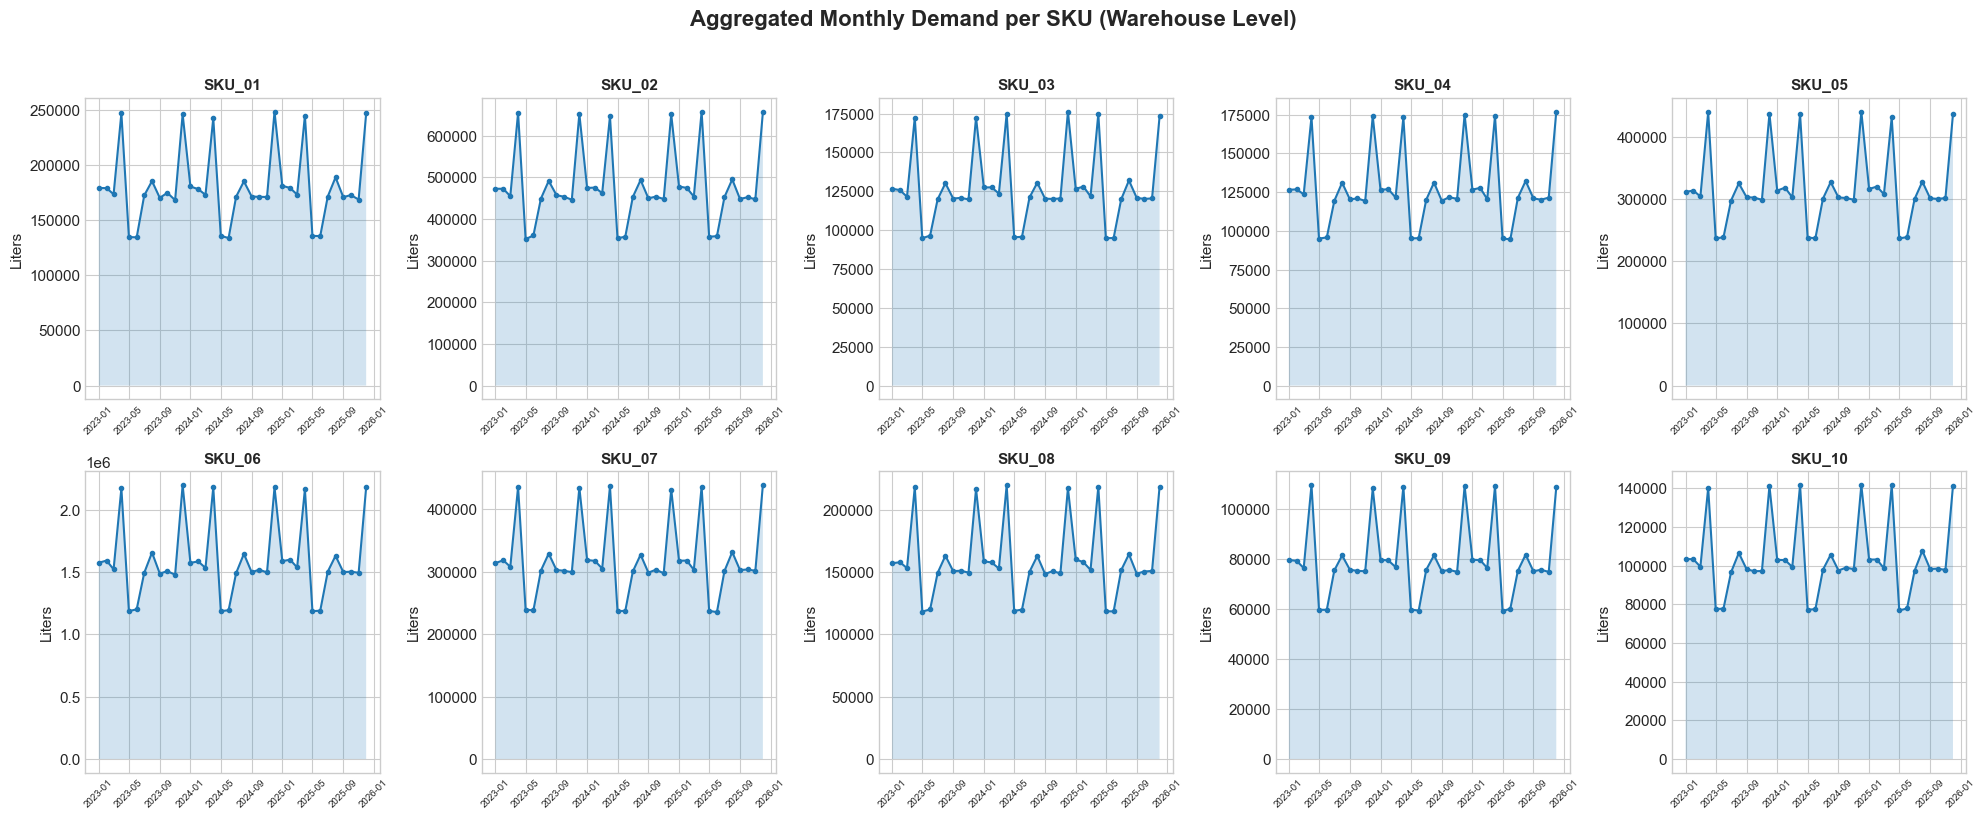

In [8]:
# 2.3 Visualize aggregated time series
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes = axes.flatten()

for i, sku in enumerate(sorted(warehouse_agg['SKU_ID'].unique())):
    sku_data = warehouse_agg[warehouse_agg['SKU_ID'] == sku].sort_values('demand_date')
    axes[i].plot(sku_data['demand_date'], sku_data['demand_liters'], 'o-', linewidth=1.5, markersize=3)
    axes[i].fill_between(sku_data['demand_date'], sku_data['demand_liters'], alpha=0.2)
    axes[i].set_title(sku, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].set_ylabel('Liters')

plt.suptitle('Aggregated Monthly Demand per SKU (Warehouse Level)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/17_aggregated_sku_series.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Feature Engineering

All features below are justified by EDA findings:
- **Lag features**: ACF/PACF analysis (EDA §4.7) showed significant autocorrelation at lags 1, 2, 3, 6, 12
- **Rolling statistics**: Gradual ACF decay → rolling means capture trend (EDA §4.7)
- **Calendar features**: Clear seasonal cycle → sin/cos encoding (EDA §4.4)
- **Holiday features**: Holiday correlation analysis (EDA §5.3)
- **Seasonality index**: Distributor seasonality labels validated (EDA §5.2)
- **Price features**: Different price points per SKU confirmed (EDA §2, Cell 10)

In [9]:
# 3.1 Lag Features
# Justified by: ACF significant at lag 1 (strongest), lag 12 (seasonal)
# PACF significant at lag 1 → recent demand is best predictor
lag_periods = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

panel = warehouse_agg.copy()
for sku in panel['SKU_ID'].unique():
    mask = panel['SKU_ID'] == sku
    for lag in lag_periods:
        panel.loc[mask, f'lag_{lag}'] = panel.loc[mask, 'demand_liters'].shift(lag)

print(f"✅ Created {len(lag_periods)} lag features: lag_1 to lag_12")
print(f"   NaN rows (expected — first 12 months per SKU): {panel['lag_12'].isna().sum()}")

✅ Created 12 lag features: lag_1 to lag_12
   NaN rows (expected — first 12 months per SKU): 120


In [10]:
# 3.2 Rolling Statistics
# Justified by: Gradual ACF decay → trend captured by rolling means
# Rolling windows: 3 (short-term), 6 (medium), 12 (annual average)
rolling_windows = [3, 6, 12]

for sku in panel['SKU_ID'].unique():
    mask = panel['SKU_ID'] == sku
    for w in rolling_windows:
        panel.loc[mask, f'roll_mean_{w}'] = panel.loc[mask, 'demand_liters'].shift(1).rolling(w, min_periods=1).mean()
        panel.loc[mask, f'roll_std_{w}'] = panel.loc[mask, 'demand_liters'].shift(1).rolling(w, min_periods=2).std().fillna(0)

print(f"✅ Created {len(rolling_windows) * 2} rolling features (mean + std for windows {rolling_windows})")

✅ Created 6 rolling features (mean + std for windows [3, 6, 12])


In [11]:
# 3.3 Calendar Features 
# Justified by: Strong 12-month seasonality (EDA §4.4)
# Sin/cos encoding preserves cyclical nature (Dec is close to Jan)
panel['month_num'] = panel['Month']
panel['quarter'] = pd.to_datetime(panel['demand_date']).dt.quarter
panel['year'] = panel['Year']
panel['month_sin'] = np.sin(2 * np.pi * panel['month_num'] / 12)
panel['month_cos'] = np.cos(2 * np.pi * panel['month_num'] / 12)

print("✅ Created 5 calendar features: month_num, quarter, year, month_sin, month_cos")

✅ Created 5 calendar features: month_num, quarter, year, month_sin, month_cos


In [12]:
# 3.4 Holiday Features
# Justified by: Holiday effect analysis (EDA §5.3)
holidays['Date'] = pd.to_datetime(holidays['Date'])
holidays['h_year'] = holidays['Date'].dt.year
holidays['h_month'] = holidays['Date'].dt.month
holidays_monthly = holidays.groupby(['h_year', 'h_month']).size().reset_index(name='holiday_count')
holidays_monthly.columns = ['Year', 'Month', 'holiday_count']

panel = panel.merge(holidays_monthly, on=['Year', 'Month'], how='left')
panel['holiday_count'] = panel['holiday_count'].fillna(0).astype(int)

print(f"✅ Created holiday_count feature")
print(f"   Range: {panel['holiday_count'].min()} to {panel['holiday_count'].max()} holidays per month")

✅ Created holiday_count feature
   Range: 4 to 26 holidays per month


In [13]:
# 3.5 Seasonality Index Feature
# Justified by: Seasonality validation (EDA §5.2)
# Encode: Un-Favorable=0, Moderate=1, Favorable=2

# Average seasonality across all distributors for each month
season_avg = seasonality.copy()
season_map = {'Un-Favorable': 0, 'Moderate': 1, 'Favorable': 2}
season_avg['season_score'] = season_avg['Seasonality_Index'].map(season_map)
season_monthly = season_avg.groupby(['Year', 'Month'])['season_score'].mean().reset_index()
season_monthly.columns = ['Year', 'Month', 'seasonality_score']

panel = panel.merge(season_monthly, on=['Year', 'Month'], how='left')
panel['seasonality_score'] = panel['seasonality_score'].fillna(1.0)

print(f"✅ Created seasonality_score feature (mean across distributors)")
print(f"   Range: {panel['seasonality_score'].min():.2f} to {panel['seasonality_score'].max():.2f}")

✅ Created seasonality_score feature (mean across distributors)
   Range: 0.50 to 2.00


In [14]:
# 3.6 Trend Feature
# Linear trend index to capture overall growth/decline
for sku in panel['SKU_ID'].unique():
    mask = panel['SKU_ID'] == sku
    panel.loc[mask, 'trend_idx'] = range(mask.sum())

# YoY ratio (current month / same month last year)
for sku in panel['SKU_ID'].unique():
    mask = panel['SKU_ID'] == sku
    panel.loc[mask, 'yoy_ratio'] = panel.loc[mask, 'demand_liters'] / panel.loc[mask, 'demand_liters'].shift(12)

panel['yoy_ratio'] = panel['yoy_ratio'].replace([np.inf, -np.inf], np.nan).fillna(1.0)

print("✅ Created trend_idx and yoy_ratio features")

✅ Created trend_idx and yoy_ratio features


📋 MULTICOLLINEARITY CHECK (|r| > 0.95)
  ⚠️ lag_1 × lag_5: r=0.970
  ⚠️ lag_1 × lag_9: r=0.974
  ⚠️ lag_1 × roll_mean_3: r=0.980
  ⚠️ lag_1 × roll_mean_6: r=0.978
  ⚠️ lag_1 × roll_mean_12: r=0.976
  ⚠️ lag_2 × lag_6: r=0.969
  ⚠️ lag_2 × lag_10: r=0.973
  ⚠️ lag_2 × roll_mean_3: r=0.981
  ⚠️ lag_2 × roll_mean_6: r=0.978
  ⚠️ lag_2 × roll_mean_12: r=0.974
  ⚠️ lag_3 × lag_7: r=0.969
  ⚠️ lag_3 × lag_11: r=0.973
  ⚠️ lag_3 × roll_mean_3: r=0.979
  ⚠️ lag_3 × roll_mean_6: r=0.972
  ⚠️ lag_3 × roll_mean_12: r=0.973
  ⚠️ lag_3 × roll_std_12: r=0.954
  ⚠️ lag_4 × lag_8: r=0.970
  ⚠️ lag_4 × lag_12: r=0.972
  ⚠️ lag_4 × roll_mean_3: r=0.958
  ⚠️ lag_4 × roll_mean_6: r=0.971
  ⚠️ lag_4 × roll_mean_12: r=0.972
  ⚠️ lag_4 × roll_std_12: r=0.972
  ⚠️ lag_5 × lag_9: r=0.971
  ⚠️ lag_5 × roll_mean_3: r=0.967
  ⚠️ lag_5 × roll_mean_6: r=0.977
  ⚠️ lag_5 × roll_mean_12: r=0.972
  ⚠️ lag_5 × roll_std_12: r=0.971
  ⚠️ lag_6 × lag_10: r=0.970
  ⚠️ lag_6 × roll_mean_3: r=0.966
  ⚠️ lag_6 × roll_mean_6: 

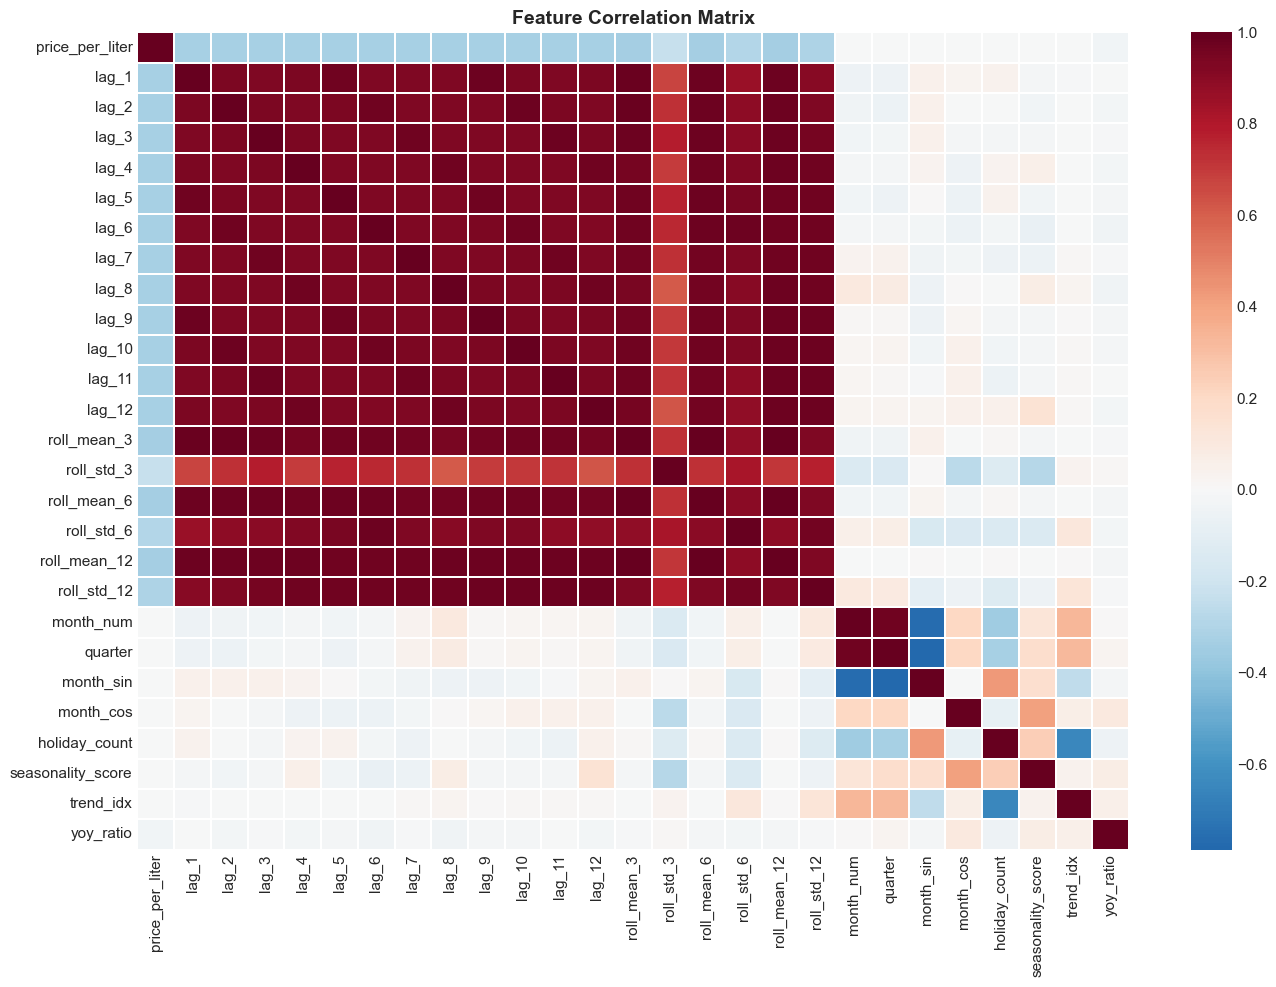

In [15]:
# 3.7 Feature Correlation Check — Multicollinearity
feature_cols = [c for c in panel.columns if c.startswith(('lag_', 'roll_', 'month_', 'quarter', 'holiday', 'season', 'trend', 'yoy', 'price'))]
feature_corr = panel[feature_cols].corr()

# Identify highly correlated pairs (>0.95)
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) > 0.95:
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], feature_corr.iloc[i, j]))

print("📋 MULTICOLLINEARITY CHECK (|r| > 0.95)")
if high_corr_pairs:
    for c1, c2, r in high_corr_pairs:
        print(f"  ⚠️ {c1} × {c2}: r={r:.3f}")
    print("\n  → These pairs are expected (e.g., lag_1 ~ roll_mean_3). Tree-based models handle this well.")
else:
    print("  ✅ No pairs with |r| > 0.95")

# Heatmap of feature correlations
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(feature_corr, annot=False, cmap='RdBu_r', center=0, ax=ax, linewidths=0.2)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/18_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# 3.8 Final Feature Summary
print("📋 FEATURE ENGINEERING SUMMARY")
print(f"\n  Panel shape: {panel.shape}")
print(f"  SKUs: {panel['SKU_ID'].nunique()}")
print(f"  Months: {panel['demand_date'].nunique()}")
print(f"\n  Feature categories:")
lag_feats = [c for c in panel.columns if c.startswith('lag_')]
roll_feats = [c for c in panel.columns if c.startswith('roll_')]
cal_feats = ['month_num', 'quarter', 'year', 'month_sin', 'month_cos']
other_feats = ['holiday_count', 'seasonality_score', 'trend_idx', 'yoy_ratio', 'price_per_liter']
print(f"    Lag features ({len(lag_feats)}):     {lag_feats}")
print(f"    Rolling features ({len(roll_feats)}):  {roll_feats}")
print(f"    Calendar features ({len(cal_feats)}):  {cal_feats}")
print(f"    Other features ({len(other_feats)}):   {other_feats}")
total_features = len(lag_feats) + len(roll_feats) + len(cal_feats) + len(other_feats)
print(f"\n  Total features: {total_features}")

📋 FEATURE ENGINEERING SUMMARY

  Panel shape: (360, 37)
  SKUs: 10
  Months: 36

  Feature categories:
    Lag features (12):     ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12']
    Rolling features (6):  ['roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12']
    Calendar features (5):  ['month_num', 'quarter', 'year', 'month_sin', 'month_cos']
    Other features (5):   ['holiday_count', 'seasonality_score', 'trend_idx', 'yoy_ratio', 'price_per_liter']

  Total features: 28


---
## 4. Train / Validation / Test Split

**Temporal split** (no shuffling — this is time series):
- **Train**: Jan 2023 – Jun 2024 (18 months)
- **Validation**: Jul 2024 – Dec 2024 (6 months) — for hyperparameter tuning
- **Test**: Jan 2025 – Dec 2025 (12 months) — held-out, untouched until final evaluation

This ensures:
1. Minimum 18 months training (≥1.5 seasonal cycles)
2. Validation captures both halves of a seasonal cycle
3. Test is a full year — evaluates all 12 calendar months

In [17]:
# 4.1 Apply temporal split
panel['split'] = 'train'
panel.loc[panel['demand_date'] >= '2024-07-01', 'split'] = 'validation'
panel.loc[panel['demand_date'] >= '2025-01-01', 'split'] = 'test'

print("📋 TEMPORAL SPLIT SUMMARY")
for split in ['train', 'validation', 'test']:
    subset = panel[panel['split'] == split]
    date_range = f"{subset['demand_date'].min().strftime('%Y-%m')} to {subset['demand_date'].max().strftime('%Y-%m')}"
    print(f"  {split:>12}: {len(subset):>4} rows | {subset['demand_date'].nunique():>2} months | {date_range}")

📋 TEMPORAL SPLIT SUMMARY
         train:  180 rows | 18 months | 2023-01 to 2024-06
    validation:   60 rows |  6 months | 2024-07 to 2024-12
          test:  120 rows | 12 months | 2025-01 to 2025-12


In [18]:
# 4.2 Drop rows with NaN lag features (first 12 months per SKU lack full lags)
before = len(panel)
panel_clean = panel.dropna(subset=['lag_12']).reset_index(drop=True)
dropped = before - len(panel_clean)

print(f"Dropped {dropped} rows with insufficient lag history (first 12 months per SKU)")
print(f"Remaining: {len(panel_clean)} rows")
print(f"\nSplit after dropping:")
for split in ['train', 'validation', 'test']:
    subset = panel_clean[panel_clean['split'] == split]
    print(f"  {split:>12}: {len(subset):>4} rows | {subset['demand_date'].nunique():>2} months")

Dropped 120 rows with insufficient lag history (first 12 months per SKU)
Remaining: 240 rows

Split after dropping:
         train:   60 rows |  6 months
    validation:   60 rows |  6 months
          test:  120 rows | 12 months


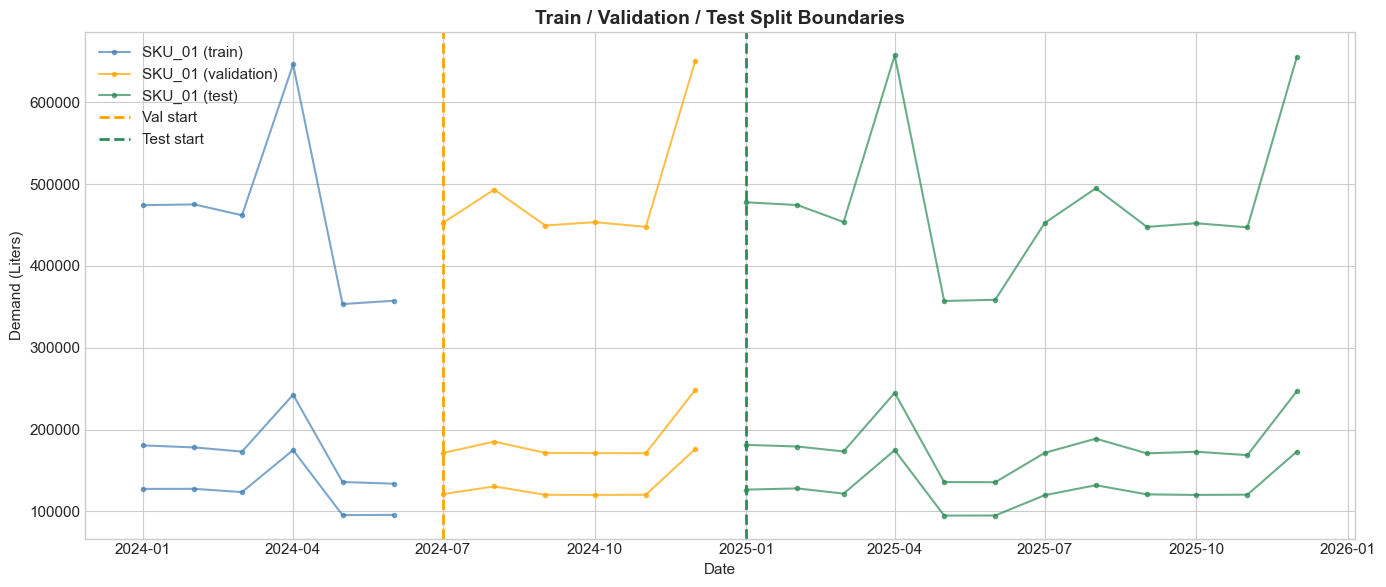

In [19]:
# 4.3 Visualize split boundaries
fig, ax = plt.subplots(figsize=(14, 6))
colors = {'train': 'steelblue', 'validation': 'orange', 'test': 'seagreen'}

for sku in sorted(panel_clean['SKU_ID'].unique())[:3]:  # Show 3 SKUs
    for split in ['train', 'validation', 'test']:
        subset = panel_clean[(panel_clean['SKU_ID'] == sku) & (panel_clean['split'] == split)].sort_values('demand_date')
        ax.plot(subset['demand_date'], subset['demand_liters'], 'o-', color=colors[split], 
                linewidth=1.5, markersize=3, alpha=0.7, label=f'{sku} ({split})' if sku == 'SKU_01' else None)

# Add vertical lines for split boundaries
ax.axvline(pd.Timestamp('2024-07-01'), color='orange', linestyle='--', linewidth=2, label='Val start')
ax.axvline(pd.Timestamp('2025-01-01'), color='seagreen', linestyle='--', linewidth=2, label='Test start')
ax.set_title('Train / Validation / Test Split Boundaries', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (Liters)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('plots/19_split_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# 4.4 Save final feature-engineered panel
output_path = 'beverage_panel_features.parquet'
panel_clean.to_parquet(output_path, index=False)
print(f"\n✅ Saved feature-engineered panel to: {output_path}")
print(f"   Shape: {panel_clean.shape}")
print(f"   Columns: {list(panel_clean.columns)}")

# Also save the full (including NaN rows) for reference
panel.to_parquet('beverage_panel_full.parquet', index=False)
print(f"\n✅ Saved full panel (incl. NaN lag rows) to: beverage_panel_full.parquet")


✅ Saved feature-engineered panel to: beverage_panel_features.parquet
   Shape: (240, 38)
   Columns: ['Year', 'Month', 'SKU_ID', 'demand_liters', 'bill_value', 'transaction_count', 'unique_outlets', 'demand_date', 'avg_volume_per_tx', 'price_per_liter', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'month_num', 'quarter', 'year', 'month_sin', 'month_cos', 'holiday_count', 'seasonality_score', 'trend_idx', 'yoy_ratio', 'split']

✅ Saved full panel (incl. NaN lag rows) to: beverage_panel_full.parquet


---
## Summary

| Step | Action | Result |
|------|--------|--------|
| Negative values | Clipped to 0 | 0.08% of rows affected |
| Categorical typos | Fixed 3 outlet types + sizes | Clean categories |
| Aggregation | Outlet → Warehouse level | 360 rows (10 SKUs × 36 months) |
| Lag features | lag_1 to lag_12 | 12 features |
| Rolling features | mean + std for windows 3, 6, 12 | 6 features |
| Calendar features | month sin/cos, quarter, year, month_num | 5 features |
| External features | holiday_count, seasonality_score | 2 features |
| Trend features | trend_idx, yoy_ratio | 2 features |
| Price feature | price_per_liter | 1 feature |
| **Total features** | | **28 features** |

**Output**: `beverage_panel_features.parquet` — ready for model training in Notebook 03.

---
*Proceed to `03_model_comparison.ipynb`*